In [2]:
!pip install git+https://github.com/amazon-science/chronos-forecasting.git -q
!pip install momentfm -q
!pip install momentfm -q


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
momentfm 0.1.4 requires huggingface-hub==0.24.0, but you have huggingface-hub 0.36.2 which is incompatible.
momentfm 0.1.4 requires transformers==4.33.3, but you have transformers 4.57.6 which is incompatible.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
chronos-forecasting 2.2.2 requires transformers<5,>=4.41, but you have transformers 4.33.3 which is incompatible.
gradio 5.49.1 requires huggingface-hub<2.0,>=0.33.5, but you have huggingface-hub 0.24.0 which is incompatible.


In [30]:
SLEEP_VECTORS_PATH = '/home/jupyter/rw-migration-local/data/sleep_vectors/'
N_VECTORS = 500


In [5]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt

from chronos import ChronosPipeline
from momentfm import MOMENTPipeline

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from kneed import KneeLocator

2026-06-12 01:04:22.041773: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-12 01:04:22.041854: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-12 01:04:22.058455: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-12 01:04:23.207140: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-12 01:04:30.096292: W tensorflow/compiler/

In [31]:
def load_chronos_model():
    pipeline = ChronosPipeline.from_pretrained(
        'amazon/chronos-t5-small',
        device_map='auto',
        torch_dtype=torch.bfloat16,
    )
    print("done")

load_chronos_model()

/opt/conda/envs/jupyter/lib/python3.10/site-packages/huggingface_hub/file_download.py:1150: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


done


In [32]:
# 1. reads each npy file
# 2. gets all the days for each participant and averages them, so each entry is an average
# of said participant's sleep
def load_sleep_vectors(path, n_vectors=None):
    files = [f for f in os.listdir(path) if f.endswith('.npy')]
    
    if n_vectors is not None:
        files = files[:n_vectors]
    
    vectors = []
    participant_ids = []
    failed = []

    for filename in files:
        pid = filename.replace('.npy', '')
        filepath = os.path.join(path, filename)
        try:
            v = np.load(filepath, allow_pickle=True)
            v_avg = v.mean(axis=0)
            vectors.append(v_avg)
            participant_ids.append(pid)
        except Exception as e:
            failed.append(pid)

    print(f"Loaded: {len(vectors)} vectors")
   

    return np.array(vectors), participant_ids

data, participant_ids = load_sleep_vectors(SLEEP_VECTORS_PATH, n_vectors=N_VECTORS)


Loaded: 500 vectors


##### some of the vectors are completely blacnk and therefore cannot be read, which is why there is an exception

## Visualization helpers

In [33]:
#Remember: Inertia = the sum of squared distances from each 
#data point to the center (centroid) of the cluster it belongs to.Inertia = the sum of squared distances 
#from each data point to the center (centroid) of the cluster it belongs to.

#1. making a list of cluster candidtes 1 to 10
#2. tests the data with that number of clusters, and for each group calculated the inertia per cluster
#3. visualize data in a plot
#4. uses the kneelocator method to find the knee
def plot_cluster_number_scores(X, k_min=1, k_max=10):
    inertia = []
    k_values = list(range(k_min, k_max + 1))

    for k in k_values:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit_predict(X)
        inertia.append(kmeans.inertia_)

    plt.figure(figsize=(7, 5))
    plt.plot(k_values, inertia, 'bx-')
    plt.xlabel('Clusters')
    plt.ylabel('Inertia')
    plt.title('Elbow Method')
    plt.show()

    kl = KneeLocator(k_values, inertia, curve='convex', direction='decreasing')
    knee_k = kl.elbow
    print(f"Recommended k (elbow): {knee_k}")

    return {'k_values': k_values, 'inertia': inertia, 'knee_k': knee_k}

# Remember: PCA- visualization tool to help figure out what is going on in multidimensional data

# 1. same clustering as before but htis time with the chosen clusters
# 2. runs PCA to help show whta the clusters look like 
# 3. visualizes, each dot shows one participant
def plot_kmeans_pca(X, k=4, title='K-means Clusters'):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)

    X_2d = PCA(n_components=2).fit_transform(X)

    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, s=60)
    plt.legend(*scatter.legend_elements(), title='Clusters')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.title(title)
    plt.show()

    return labels, X_2d, kmeans


def plot_vectors_by_cluster(vectors, labels, k=4, title_prefix='Cluster'):
    vectors_24 = vectors

    for c in range(k):
        cluster_vectors = vectors_24[labels == c]

        plt.figure(figsize=(12, 5))
        plt.imshow(cluster_vectors, cmap='Greens', origin='lower', aspect='auto', vmin=0, vmax=1)
        plt.colorbar(label='Fraction of hour slept')
        plt.title(f'{title_prefix} {c}: {cluster_vectors.shape[0]} vectors')
        plt.ylabel('Participant')
        plt.xlabel('Hour of day (0-23)')

        plt.xticks(range(0, 24, 3))
        plt.grid()
        plt.show()

 data: (500, 24)


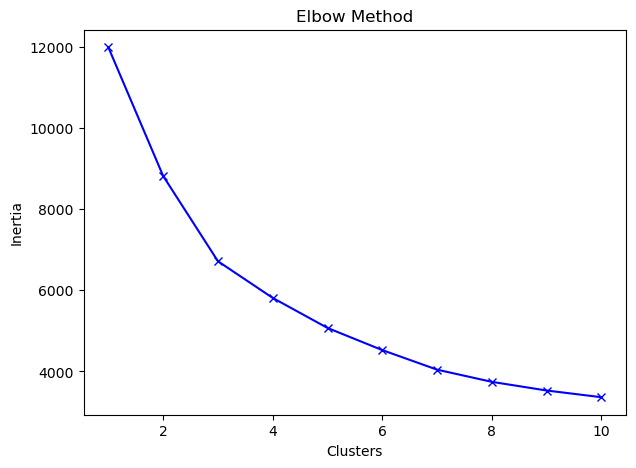

Recommended k (elbow): 3


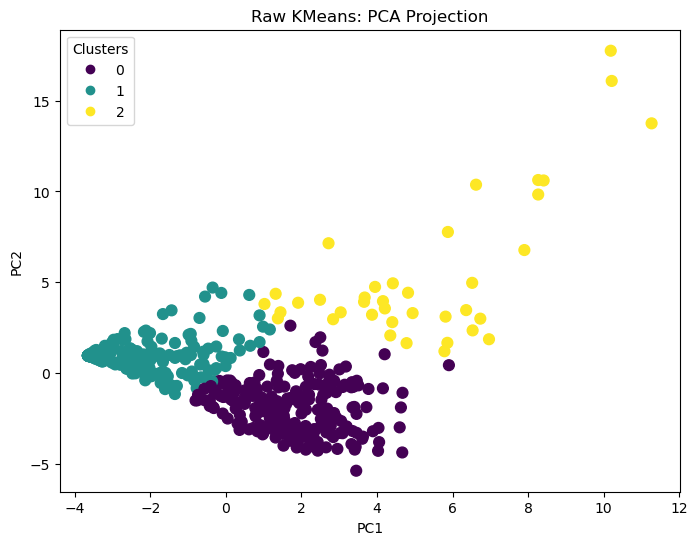

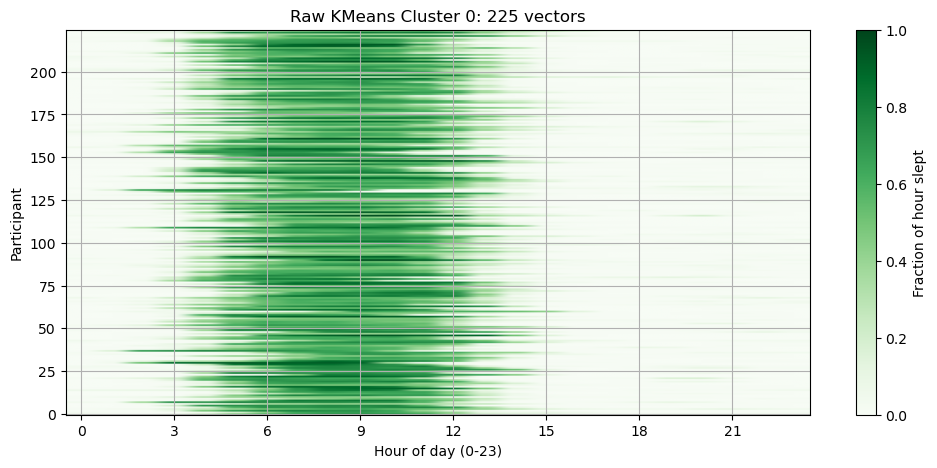

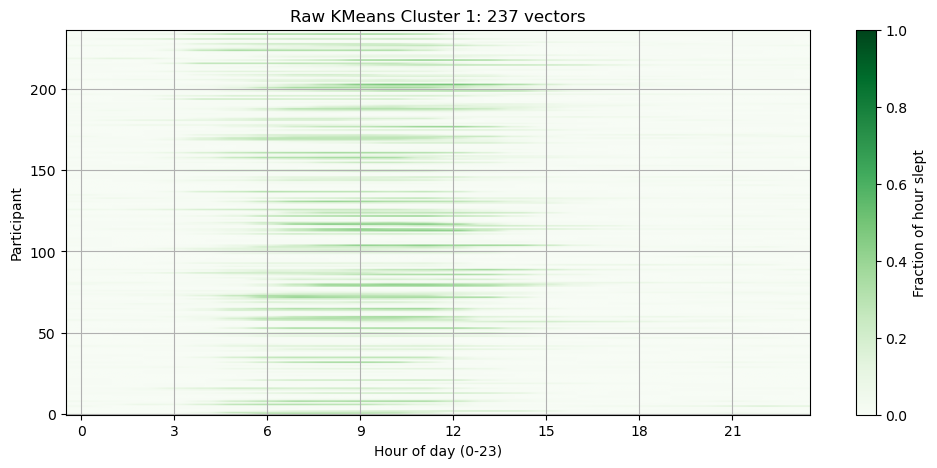

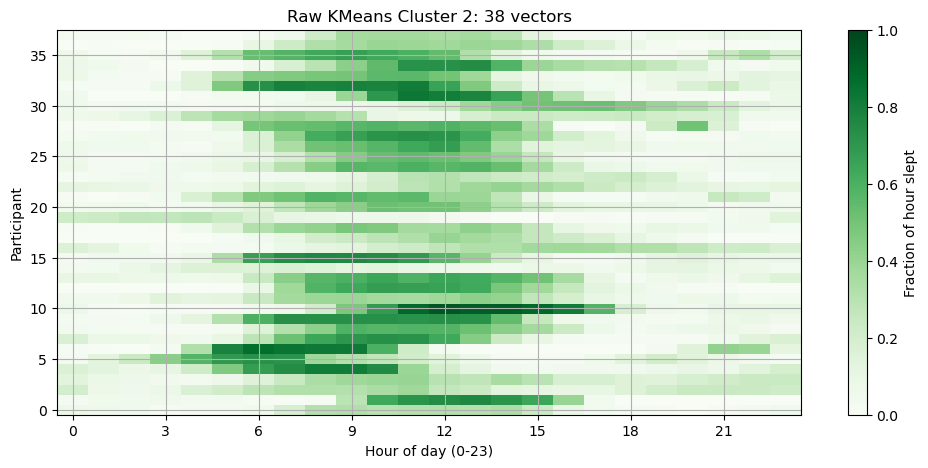

In [34]:
# 1. normalizing data
# 2. gets the elbow plot information
# 3. plots the PCA


def run_kmeans_clustering(data, title_prefix='Raw KMeans'):

    print(f" data: {data.shape}")

    X = StandardScaler().fit_transform(data)

    scores = plot_cluster_number_scores(X, k_min=1, k_max=10)
    k = scores['knee_k']

    labels, X_2d, kmeans = plot_kmeans_pca(X, k=k, title=f'{title_prefix}: PCA Projection')
    plot_vectors_by_cluster(data, labels, k=k, title_prefix=f'{title_prefix} Cluster')

    return labels, k


kmeans_labels, kmeans_k = run_kmeans_clustering(data)

Loading Chronos model...


/opt/conda/envs/jupyter/lib/python3.10/site-packages/huggingface_hub/file_download.py:1150: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Embedding vectors...


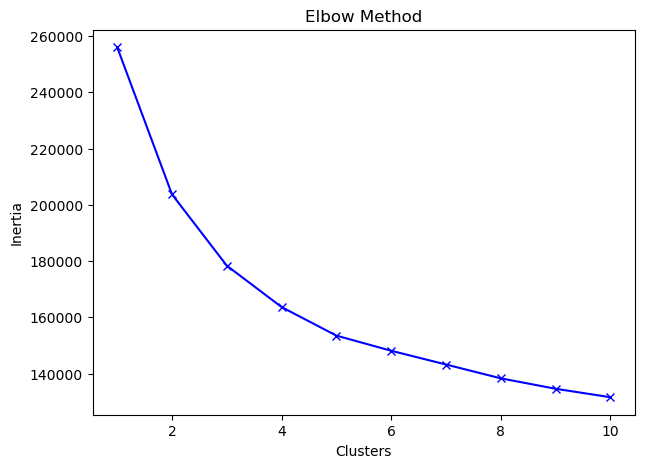

Recommended k (elbow): 4


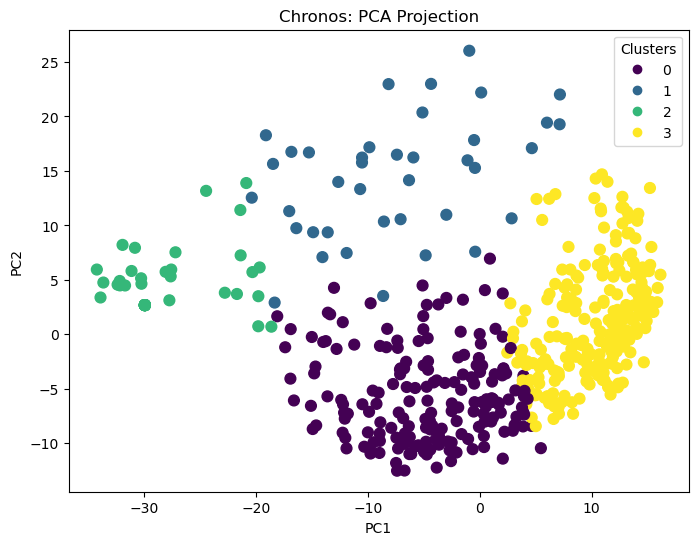

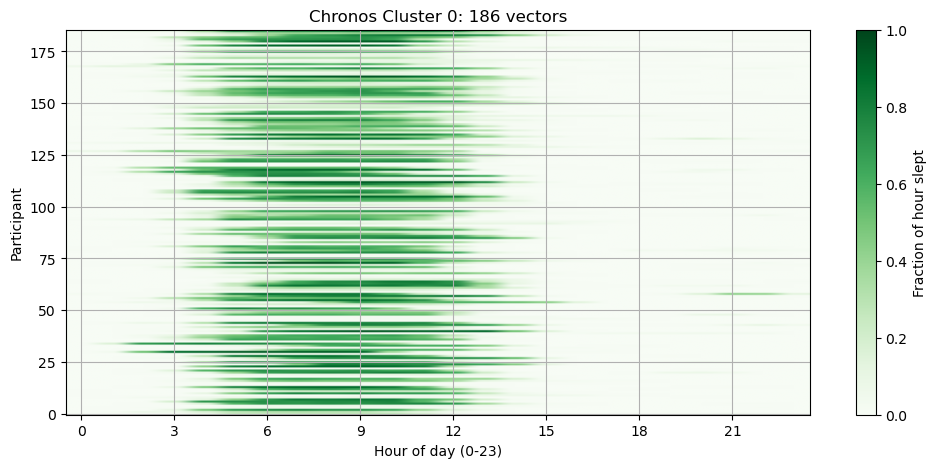

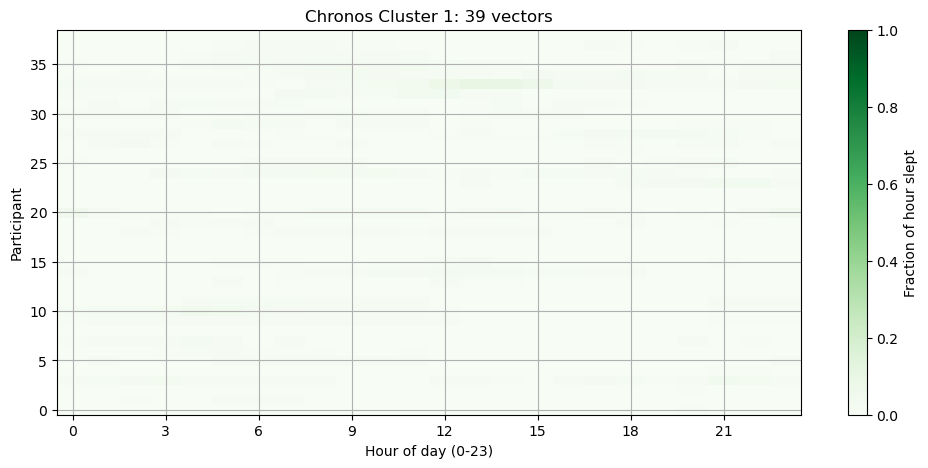

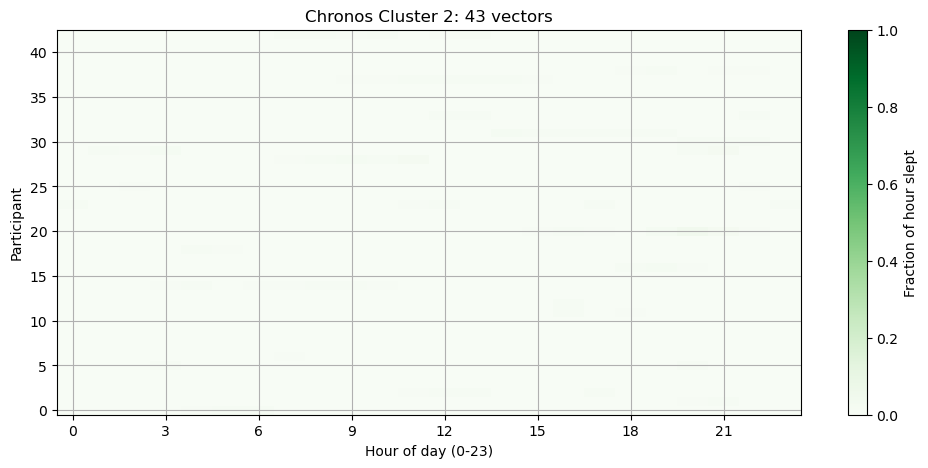

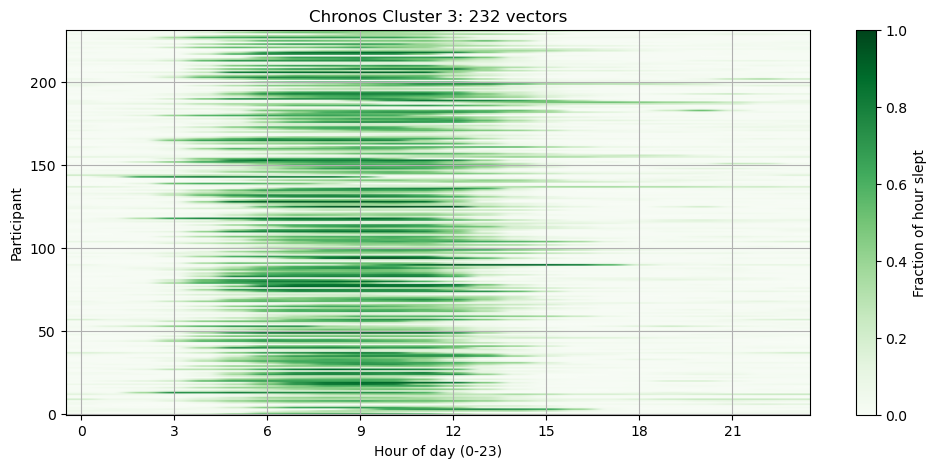

Cluster 0: 186 participants
  Min: 0.0000, Max: 0.9657, Mean: 0.1410
Cluster 1: 39 participants
  Min: 0.0000, Max: 0.1045, Mean: 0.0054
Cluster 2: 43 participants
  Min: 0.0000, Max: 0.0407, Mean: 0.0008
Cluster 3: 232 participants
  Min: 0.0000, Max: 0.9710, Mean: 0.1735


In [35]:
def run_chronos_clustering(data, title_prefix='Chronos'):

    print("Loading Chronos model...")
    pipeline = ChronosPipeline.from_pretrained(
        'amazon/chronos-t5-small',
        device_map='auto',
        torch_dtype=torch.bfloat16,
    )

    data_2d = data.reshape(data.shape[0], -1)

    print("Embedding vectors...")
    sleep_tensors = [torch.tensor(row, dtype=torch.float32) for row in data]
    
    with torch.no_grad():
        embeddings, _ = pipeline.embed(sleep_tensors)
    
    chronos_X = embeddings.mean(dim=1).float().cpu().numpy()
    
    X = StandardScaler().fit_transform(chronos_X)
    
    scores = plot_cluster_number_scores(X, k_min=1, k_max=10)
    k = scores['knee_k']
    
    labels, X_2d, kmeans = plot_kmeans_pca(X, k=k, title=f'{title_prefix}: PCA Projection')
    
    plot_vectors_by_cluster(data, labels, k=k, title_prefix=f'{title_prefix} Cluster')
    
    return labels, k


chronos_labels, chronos_k = run_chronos_clustering(data)


import numpy as np

for c in range(chronos_k):
    cluster_data = data[chronos_labels == c]
    print(f"Cluster {c}: {cluster_data.shape[0]} participants")
    print(f"  Min: {cluster_data.min():.4f}, Max: {cluster_data.max():.4f}, Mean: {cluster_data.mean():.4f}")

Loading MOMENT model...
Embedding vectors...


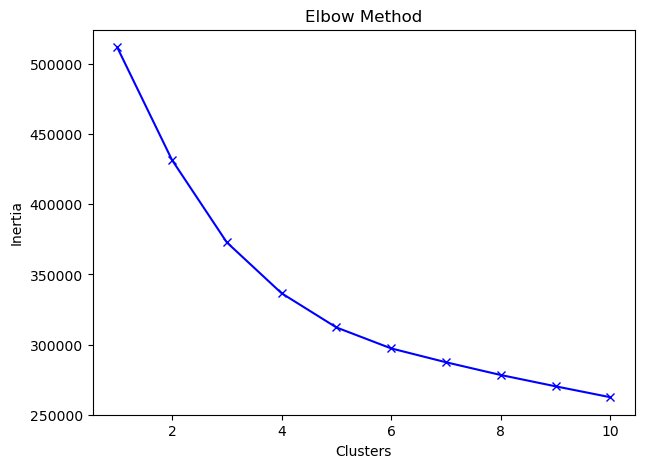

Recommended k (elbow): 4


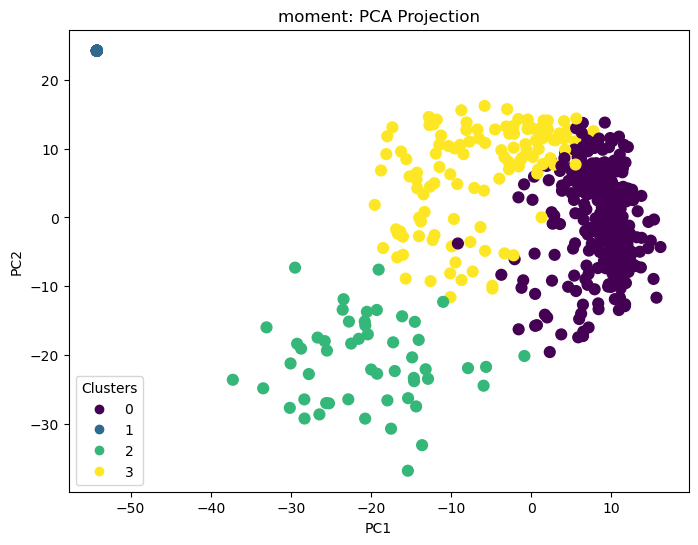

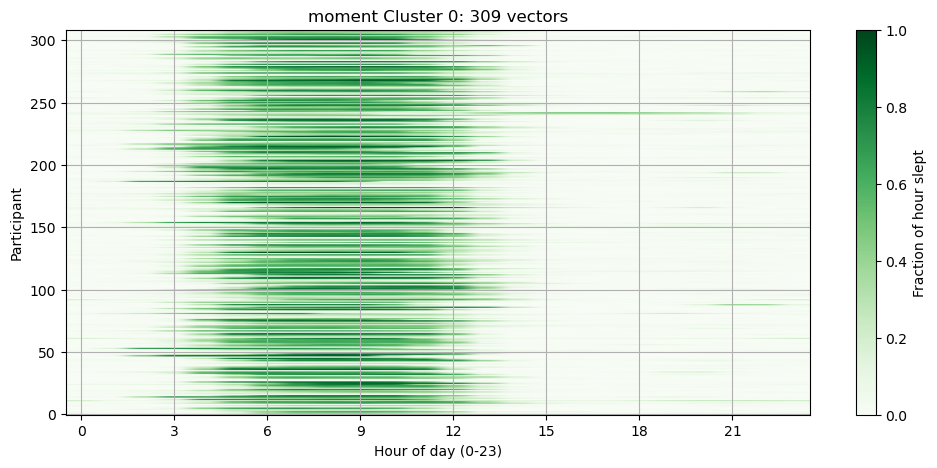

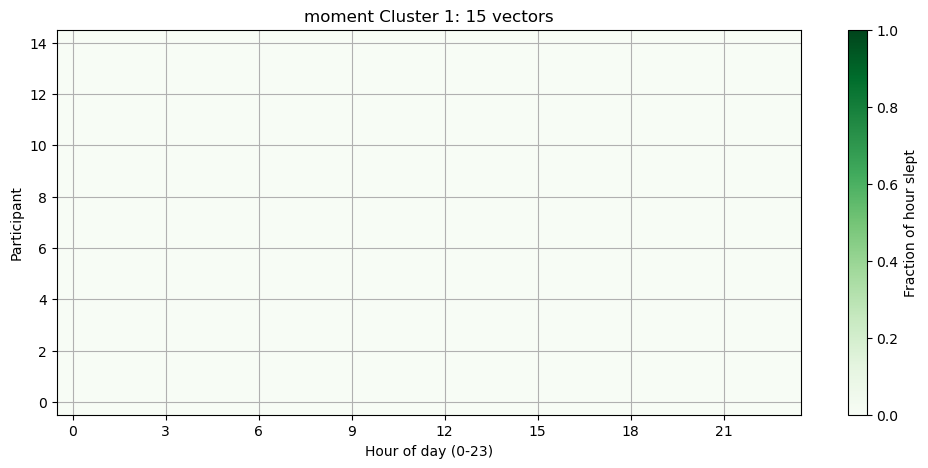

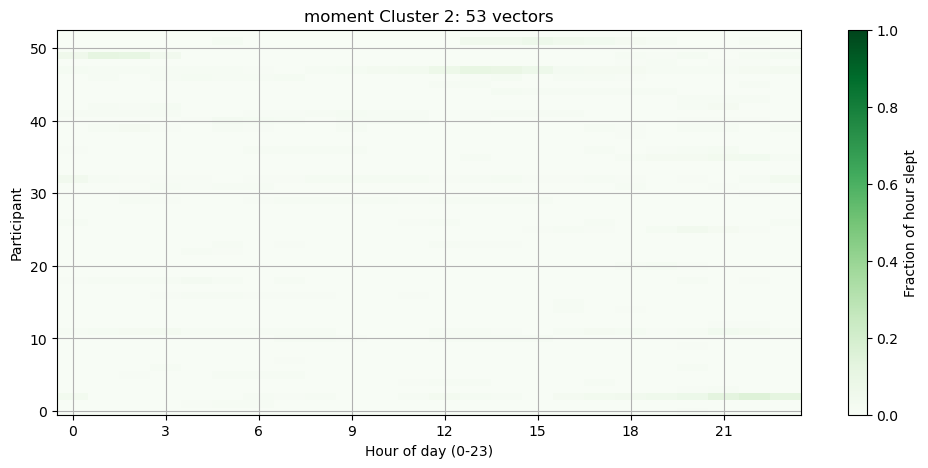

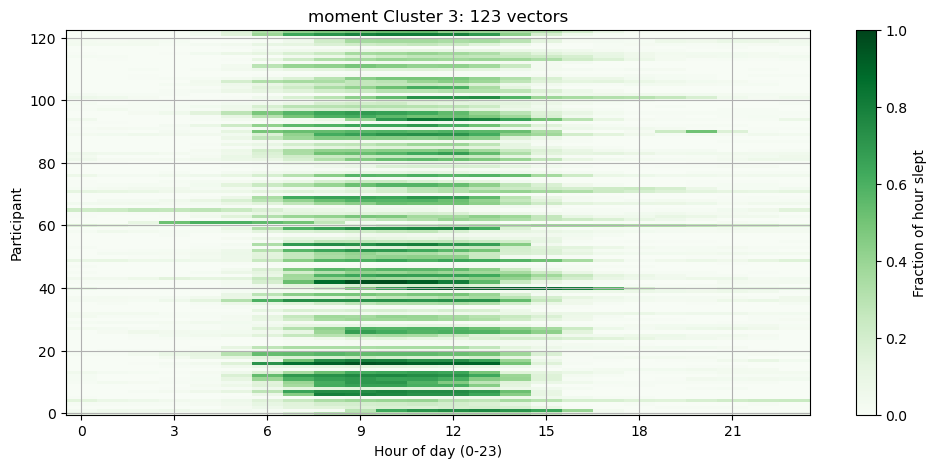

In [39]:
def run_moment_clustering(data, title_prefix='MOMENT'):

    print("Loading MOMENT model...")

    from momentfm import MOMENTPipeline

    model = MOMENTPipeline.from_pretrained(
        "AutonLab/MOMENT-1-large",
        model_kwargs={
            "task_name": "embedding"
        }
    )

    model.init()
    model.eval()

    print("Embedding vectors...")

    data_2d = data.reshape(data.shape[0], -1)

    sleep_tensors = torch.tensor(data_2d, dtype=torch.float32).unsqueeze(1)

    with torch.no_grad():
        output = model(x_enc=sleep_tensors)

    moment_X = output.embeddings.detach().cpu().numpy()

    if moment_X.ndim > 2:
        moment_X = moment_X.reshape(moment_X.shape[0], -1)

    X = StandardScaler().fit_transform(moment_X)

    scores = plot_cluster_number_scores(X, k_min=1, k_max=10)
    k = scores['knee_k']

    labels, X_2d, kmeans = plot_kmeans_pca(
        X,
        k=k,
        title=f'{title_prefix}: PCA Projection'
    )

    plot_vectors_by_cluster(
        data,
        labels,
        k=k,
        title_prefix=f'{title_prefix} Cluster'
    )

    return labels, k

moment_labels, moment_k = run_moment_clustering(data, "moment")
